In [3]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import joblib
import matplotlib.pyplot as plt


df = pd.read_csv('air-quality-london-time-of-day.csv')   # or whatever your exact filename is

print("Columns in your file:", df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())

Columns in your file: ['Month (text)', 'GMT', 'London Mean Roadside:Nitric Oxide (ug/m3)', 'London Mean Roadside:Nitrogen Dioxide (ug/m3)', 'London Mean Roadside:Oxides of Nitrogen (ug/m3)', 'London Mean Roadside:Ozone (ug/m3)', 'London Mean Roadside:PM10 Particulate (ug/m3)', 'London Mean Roadside:PM2.5 Particulate (ug/m3)', 'London Mean Roadside:Sulphur Dioxide (ug/m3)', 'London Mean Background:Nitric Oxide (ug/m3)', 'London Mean Background:Nitrogen Dioxide (ug/m3)', 'London Mean Background:Oxides of Nitrogen (ug/m3)', 'London Mean Background:Ozone (ug/m3)', 'London Mean Background:PM10 Particulate (ug/m3)', 'London Mean Background:PM2.5 Particulate (ug/m3)', 'London Mean Background:Sulphur Dioxide (ug/m3)']

First 5 rows:
  Month (text)    GMT  London Mean Roadside:Nitric Oxide (ug/m3)  \
0       Jan-08  00:00                                        NaN   
1       Jan-08  01:00                                        NaN   
2       Jan-08  02:00                                        

In [4]:
# Combine Month and GMT into proper datetime
df['datetime'] = pd.to_datetime(df['Month (text)'] + ' ' + df['GMT'], format='%b-%y %H:%M')

df = df.sort_values('datetime')
df.set_index('datetime', inplace=True)

In [5]:
# Choose target: Nitrogen Dioxide (Roadside) - most common pollutant
target_col = 'London Mean Roadside:Nitrogen Dioxide (ug/m3)'
df = df[[target_col]].copy()
df.rename(columns={target_col: 'NO2'}, inplace=True)

In [6]:
# Fill missing values with forward fill (common for time-series)
df['NO2'] = df['NO2'].ffill()

print("Cleaned Data Shape:", df.shape)
print(df.head())

Cleaned Data Shape: (3336, 1)
                      NO2
datetime                 
2008-01-01 00:00:00  42.3
2008-01-01 01:00:00  33.8
2008-01-01 02:00:00  28.8
2008-01-01 03:00:00  27.3
2008-01-01 04:00:00  29.4


In [7]:
df['lag1'] = df['NO2'].shift(1)
df['lag2'] = df['NO2'].shift(2)
df['lag3'] = df['NO2'].shift(3)
df['month'] = df.index.month
df['hour'] = df.index.hour
df['weekday'] = df.index.weekday

df.dropna(inplace=True)

In [8]:
X = df[['lag1', 'lag2', 'lag3', 'month', 'hour', 'weekday']]
y = df['NO2']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

model = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42)
model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [9]:
preds = model.predict(X_test)
print("\n=== Model Performance ===")
print("MAE: ", round(mean_absolute_error(y_test, preds), 2))
print("RMSE:", round(mean_squared_error(y_test, preds)**0.5, 2))
print("R² Score:", round(r2_score(y_test, preds), 3))


=== Model Performance ===
MAE:  2.18
RMSE: 3.28
R² Score: 0.901


In [12]:
import os
import joblib

os.makedirs("models", exist_ok=True)

joblib.dump(model, "models/xgboost_no2_predictor.pkl")

print("\n✅ Model saved successfully!")


✅ Model saved successfully!


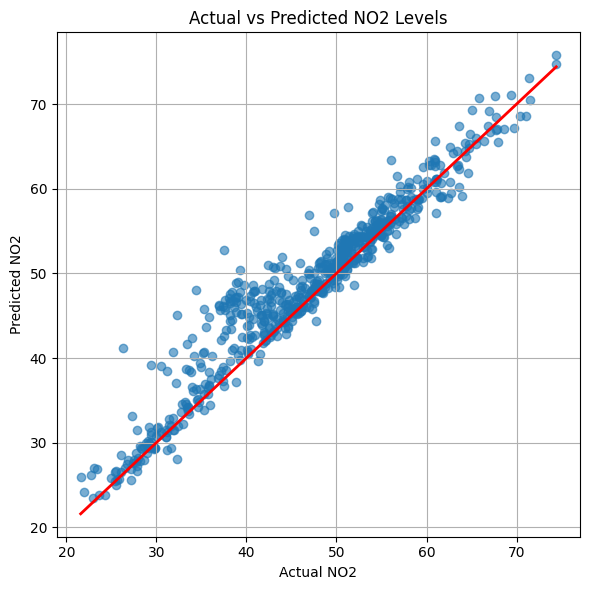

In [15]:
import matplotlib.pyplot as plt
y_pred = model.predict(X_test)
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linewidth=2)

plt.xlabel("Actual NO2")
plt.ylabel("Predicted NO2")
plt.title("Actual vs Predicted NO2 Levels")

plt.grid(True)
plt.tight_layout()

plt.show()